# ASP3231 Laboratory 4: Calibrated Catalogues

In this week's laboratory we going to use archival data to estimate V-band magnitudes of bright stars, create a catalogue of celestial objects using Monash C14 data and use that catalogue to produce a histogram of astronomical magnitudes.

## Prelab Questions

You are expected to read the lab notebook prior to the lab, and the Prelab Questions are designed to prompt you to consider what you have read. This will hopefully prepare you for the lab session and ultimately save time.

#### Question 1: Why do the magnitudes of stars depend on the filter they are measured in?

#### Question 2: If a star has a colour of B-V=0 why does it typically have roughly U-B=0 and V-R=0 too (for Vega-basd magnitudes)?

#### Question 3: Open AladinLite (https://aladin.u-strasbg.fr/AladinLite/), find NGC 4755 (Jewel Box) and use the SIMBAD catalogue to determine the name and V-band magnitude of a star. (Note SIMBAD magnitudes are archival and of varying quality, sometimes using CCD photometry but on occassion using photographic plate photometry).

#### Question 4: Plot a parabola in using matplotlib. There's plenty of resources online, but make significant changes if you make use of online resources and comment your code accordingly.

#### Question 5: Produce a histogram using matplotlib for a list that you've written yourself. Have at least ten numbers in your list. 


<font color=green>

**Question 1:** Stars do not emit light equally across all wavelengths. We can often assume they are blackbodies, but this isn't always the case. A very bright blue star will still appear dimmer in a red filter. 

**Question 2:** The star Vega is, by definition, given a magnitude of 0 in the U, B, V, R, and I filters. If a star were to coincidentally have B-V=0, it would essentially have a similar colour index to that of Vega, and we could then predict that U-B and V-R would also be approximately zero due to our definition of the magnitudes.

**Question 3:** NGC 4755 407 is a star in NGC 4755 with a V-band magnitude of 12.81.

**Question 4 and 5:** Refer to next code cell.

</font>

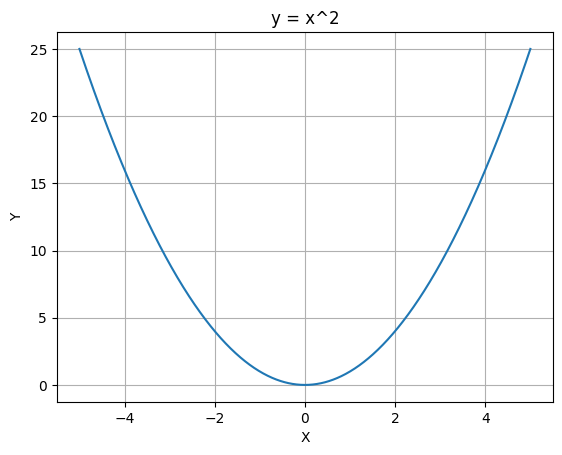

[7 1 3 3 7 2 2 7 7 7 6 1 7 3 2]


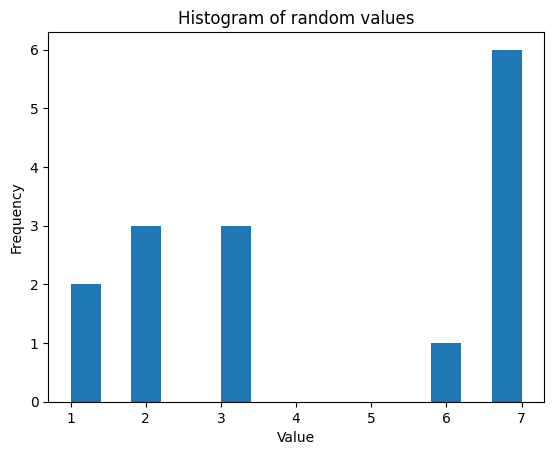

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Create an array of x-coordinates
x = np.linspace(-5, 5, 1000)
# Map to y-coordinates with f(x)
y = x**2

# Plotting logic
plt.figure(0)
plt.plot(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("y = x^2")
plt.grid()
plt.show()

# Generate a random 12-element array of integers to display
rng = np.random.default_rng()
histogram_list = rng.integers(low=1, high=8, size=(15))
print(histogram_list)
# Plotting logic
plt.figure(1)
plt.hist(histogram_list, bins=len(histogram_list))
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of random values")
plt.show()

**Task 1.** As always we import various libraries. A new one this week is astroquery - what does it do?

In [1]:
# Import various libraries 

import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii

from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.background import Background2D
from photutils.background import MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation  import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import gc                               

from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia


/Users/alec/honours-env/.venv/lib/python3.11/site-packages/google_crc32c/__init__.py:29: RuntimeWarning: As the c extension couldn't be imported, `google-crc32c` is using a pure python implementation that is significantly slower. If possible, please configure a c build environment and compile the extension
  warnings.warn(_SLOW_CRC32C_WARNING, RuntimeWarning)


The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


For our photometric calibration we will use a star in our science field with Gaia photometry. To convert from the Gaia band photometry in the UBVRI band photometry we must model the relationship between UBVRI photometry and Gaia photometry using stars with well measured magnitudes. This is done using Graham (1982) UBVRI standard stars that have Gaia photometry.

A csv file of the Graham (1982) standards with Gaia photometry is already available. We can load this into our notebook into the form of a table. 

**Task 2.** Read the Graham - Gaia data into a table, and add to the code below to print an example row and an example column.

In [ ]:

Graham = ascii.read("GrahamGaia.csv", format='csv', fast_reader=False)

print(Graham)  # Example data from Graham

# Write your own code to print an example row

# Write your own code to print an example column (hint - what are the columns called?) 

**Task 3.** Lets now plot V minus G as a function of Gaia G_BP minus G, and fit that data. Write the equation that gives V band magnitude as a function of Gaia photometry. This equation allows us to estimate V-band magnitudes from Gaia magnitudes for main sequence stars, while correcting for the difference between V-band and Gaia G. 


In [ ]:
# Plot the difference between V and G as a function of Gaia G_BP and G.

# What is px and py? What is the if statement doing?
px=[]        # Comment
py=[]        # Comment
for Star in Graham:
    # Check if we have valid Graham and Gaia magnitudes and colours.
    # Remember we sometimes use -99 to denote a missing value. 
    if Star['Vmag']>0.0 and Star['Vmag']<30.0 and \
    Star['GBP']>0.0 and Star['GBP']<30.0 and \
    Star['G']>0.0 and Star['G']<30.0 and \
    (Star['Vmag']-Star['G'])**2<2.25 :         # Only match if V and G are similar
        px.append(Star['GBP']-Star['G'])      # G_BP minus G
        py.append(Star['Vmag']-Star['G'])          # V minus G

plt.title('V minus G as a function of colour')       # Title
plt.ylabel('Graham V - Gaia G')                      # y-label
plt.xlabel('Gaia G_BP - Gaia G')                     # x-label
plt.scatter(px, py, marker='o');                     # What is this plotting?    

# Fit to this data 

# What is px and py? What is the if statement doing?
px=[]        # Comment
py=[]        # Comment
for Star in Graham:
    # Check if we have valid Graham and Gaia magnitudes and colours.
    # Remember we sometimes use -99 to denote a missing value. 
    if Star['Vmag']>0.0 and Star['Vmag']<30.0 and \
    Star['GBP']>0.0 and Star['GBP']<30.0 and \
    Star['G']>0.0 and Star['G']<30.0 and \
    Star['GBP']-Star['G']>0.0 and \
    (Star['Vmag']-Star['G'])**2<2.25 :             # Only match if V and G are similar
        px.append(Star['GBP']-Star['G'])           # G_BP minus G
        py.append(Star['Vmag']-Star['G'])          # V minus G

# What does polyfit do doing?
Vpoly=np.polyfit(px, py, 2)                           
print(Vpoly)                                          

# What are plx and ply? If you are unsure print their values.
plx=np.arange(-0.1, 1.3, 0.1).tolist()
ply=[]
for x in plx:
    ply.append(Vpoly[2]+Vpoly[1]*x+Vpoly[0]*x*x)

plt.title('V minus G as a function of colour')       # Title
plt.ylabel('Graham V - Gaia G')                      # y-label
plt.xlabel('Gaia G_BP - Gaia G')                     # x-label
plt.scatter(px, py, marker='o');                     # What is this plotting?    
plt.plot(plx, ply, linestyle='dashed', linewidth=2); # What is this plotting?


#### Rewrite V-G as a function of GBP-G to get V from Gaia photomety 


**Task 4.** Adapt the code above to plot and fit Graham R minus Gaia G_RP as a function of Gaia G minus Gaia G_RP. This allows us to estimate R-band magnitudes from Gaia magnitudes for main sequence stars, while accounting for the difference between the R-band and G_RP band.

**Hint:** Don't reuse Vpoly and instead create Rpoly.

**Task 5.** A bright star in Jewel Box (HD 111990) is located at RA=193.49911961463 DEC=-60.33542302933, and has G_BP=6.85, G=6.69 and G_RP=6.43. Run the following Gaia query to confirm the photometry.

In [ ]:
# Set Gaia magnitudes to junk values 
gmag=[-99.0, -99.0, -99.0]

# Get coordinates in decimal degrees - note the original script has placeholder values
rad=123.4
decd=56.7

coord = SkyCoord(ra=rad, dec=decd, unit=(u.degree, u.degree), frame='icrs')
# Match radius in degrees
radius = u.Quantity(0.001, u.deg)

# Run query and return results
j = Gaia.cone_search_async(coordinate=coord, radius=radius)
r = j.get_results()
# If there is a result then print the first match
if len(r)>0:
    print(r[0]['phot_bp_mean_mag'])
    print(r[0]['phot_g_mean_mag'])
    print(r[0]['phot_rp_mean_mag'])
    # What do I need to do here to get the magnitudes into the gmag list?

**Task 6.** Determine the V and R band magnitudes for this star. To do this use your previous results for V - G as a function of G_BP - G, and R - G_RP as a function of G - G_RP. (If the Gaia query did not run then use the values stated in the notebook.)

**Task 7.** We are now going to generate a catalogue of objects for the Jewel Box Cluster. As the stars in our Jewel Box image are reasonably well seperated, we will use the segmentation (rather than model fit approach). Run the following code and comment on what each line is doing and what the plot shows (add axis labels and a caption).

Today's image, new-image.fits, is a copy of an image taken with the C14 telescope with a world coordinate system added using astrometry.net. 

In [ ]:
scim=CCDData.read("new-image.fits", unit="adu")   # Read the image

w = scim.wcs                                      # Read the World Coordinate System
print(w)

med=np.median(scim.data)                          # Median pixel value
scim.data=scim.data-med                           # Use the median for the sky subtraction
mean, median, std = astropy.stats.sigma_clipped_stats(scim.data, sigma=3.0, maxiters=5)    
print('Image stats (mean, median and standard deviation):', mean,median,std)

segimage=detect_sources(scim.data, 2.00*std, 9, connectivity=4, mask=None)


**Task 8.** Comment on what is being plotted here. How does segimage (segmentation image) compare to the ds9 image of Jewel Box?

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(segimage.data, cmap='gray', vmin=0, vmax=1, origin='lower')


**Task 9.** The following code writes the segmentation image to an output FITS file. Compare the segmentation image with the original image using ds9, and discuss what you see (i.e. how the images differ, and the pixel values for the segmentation map).

In [ ]:
outfile="segimage.fits"                # Set the output file name
hdu=fits.PrimaryHDU(segimage)          # Define a FITS header for this data
# Convert WCS to header format
wcsheader = w.to_header(relax=True)
hdu.header.extend(wcsheader)
hdu.writeto(outfile, overwrite=True)   # Write the output and overwrite existing files if needed. 


**Task 10.** Let's now convert the segmentation map into a catalogue of object positions using the following code.


In [ ]:
source_table=SourceCatalog(scim.data, segimage, error=None, mask=None, background=None, wcs=w)
print('Source table length:\n', len(source_table))
print('\n\n')
print('First entry centroid x and y values :') 
print(source_table[0].centroid[0], source_table[0].centroid[1])
print('\n\n')
print('First source sky icrs coordinates :') # 
print(source_table[0].sky_centroid_icrs)
print(source_table[0].sky_centroid_icrs.ra, source_table[0].sky_centroid_icrs.dec)


**Task 11.** The following code switches the source table list of centroids into a list of positions that can then be used for photometry. Adapt code from previous weeks to now run 20 pixel radius aperture photometry on this list of object positions.


In [ ]:
positions=[]
for obj in source_table:                                   # Step through list of sources
    positions.append((obj.centroid[0], obj.centroid[1]))   # Positions for source photometry are x-y
print(positions[0:10])                                     # Print example values from the positions list.



**Task 12.** What flux (counts) have you measured for the bright star HD 111990 in Jewel Box that is located at RA=193.49911961463 DEC=-60.33542302933? Use https://aladin.u-strasbg.fr/AladinLite/ and ds9 to identify this star identify this star in your images and to get some of this star's key details. (Remember SIMBAD magnitudes are archival and of varying quality, sometimes using CCD photometry but on occassion using very old photographic plate photometry.)

ds9 usually displays coordinates in h\:m\:s and d\:m\:s format, but this can be changed to decimal degrees using the WCS menu.

In [ ]:
# Clue - here's ways to query a range of positions in a photometry table
# Clue for projects - if you have a list of photometry tables, you may 
# need to do a for loop over phot_tables[0] rather than phot_table

for idx, obj in enumerate(phot_table):
    c1 = SkyCoord('123.0deg', '0.456deg', frame='icrs')
    c2 = SkyCoord(source_table[idx].sky_centroid_icrs.ra, source_table[idx].sky_centroid_icrs.dec, frame='icrs')
    sep = c1.separation(c2)
    # print(sep)
    if sep.value<10.0/3600.0:
        print('Separation less than 10 arcseconds')
        print(c1, c2)
        print(obj)

**Task 13.** Determine the V-band magnitude of the fainter star near x=1444 y=629 using the flux of this star in ADU (from phot_table) and the estimated V-band magnitude and flux in ADU of HD 111990. This is simply using:
\begin{equation}
m_1 - m_2 = -2.5{\rm log_{10}} \left(\frac{f_1}{f_2} \right)
\end{equation}

Take care to use np.log10 and not np.log (which is natural log).

In [ ]:
# This code can help get you started. 
# What is it doing and how does it compare to the previous task?

# What are these coordinates?
xstar = 1234.0 
ystar = 321.0

for idx, obj in enumerate(phot_table):
    if (obj['xcenter'].value-xstar)**2+(obj['ycenter'].value-ystar)**2<10.0**2:
        print(obj)

**Task 14.** Is there a way you could check your V-band magnitude above is in the right ballpark? Can you compare to other stars or use an online database? This could be a test done manually with a web interface or an automated query. 

**Task 15.** Produce a list (array) of V-band magnitudes for all the stars in Jewel Box.

In [ ]:
maglist=[]
for obj in phot_table:
    maglist.append(1)
print(maglist)

**Task 16.** Produce a histogram of the magnitudes of the stars in Jewel Box using matplotlib. Ideally set the range so the bin width is 0.5 mag per bin. 

Hint: https://stackoverflow.com/questions/33203645/how-to-plot-a-histogram-using-matplotlib-in-python-with-a-list-of-data

Hint: Ideally you should only plot plausible magnitudes (i.e. not -90 and not +90).


# Don't forget your conclusions